In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Baca dataset MNIST CSV
df = pd.read_csv('/content/drive/MyDrive/prakpola/dataset/mnist_train.csv')  # atau ganti dengan path file Anda
print("Jumlah data:", len(df))
df.head()

Jumlah data: 60000


,label,1x1,1x2,1x3,1x4,1x5,1x6,1x7,1x8,1x9,...,28x19,28x20,28x21,28x22,28x23,28x24,28x25,28x26,28x27,28x28
0,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


<ipython-input-3-b493139ab4b6>:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  label = row[0]


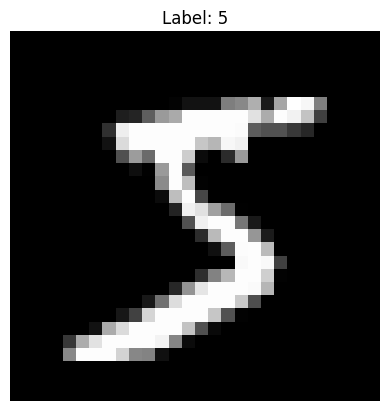

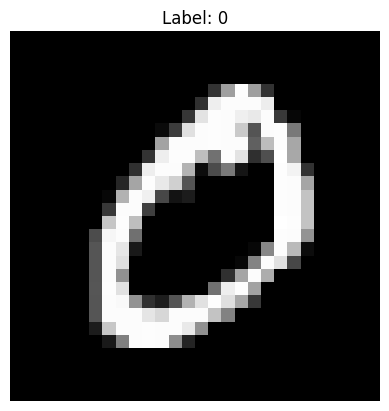

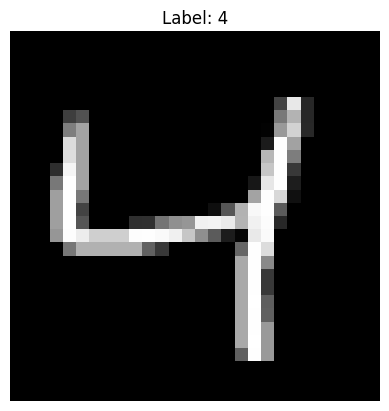

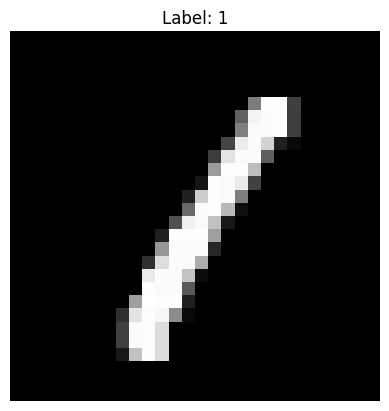

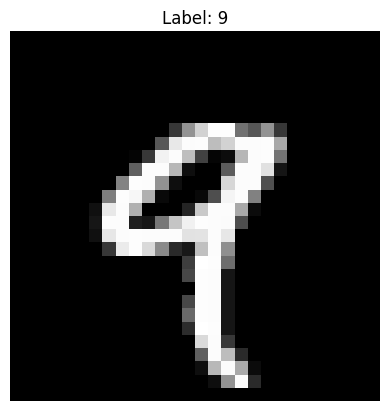

In [ ]:
def show_image(row):
    label = row[0]
    pixels = np.array(row[1:]).reshape(28, 28)
    plt.imshow(pixels, cmap='gray')
    plt.title(f"Label: {label}")
    plt.axis('off')
    plt.show()

# Tampilkan 5 contoh gambar
for i in range(5):
    show_image(df.iloc[i])

Bagian ini disebut ekstraksi fitur karena kita mengubah gambar (piksel 28x28) menjadi vektor histogram, Ini mengekstrak 256 fitur dari tiap gambar berdasarkan distribusi intensitas piksel (0–255), yang kemudian digunakan untuk klasifikasi.

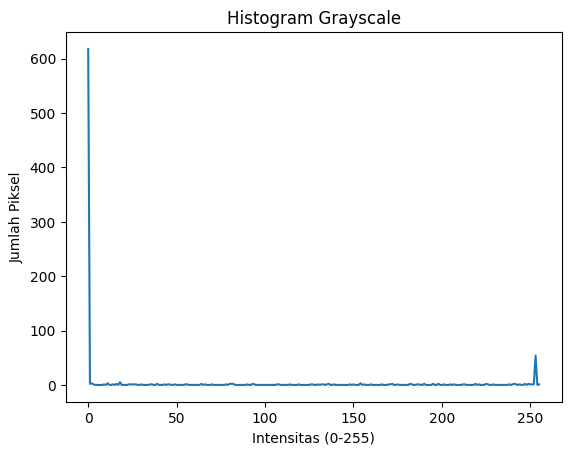

In [ ]:
#Ekstrasi fitur
def get_histogram(row):
    pixels = np.array(row[1:])
    hist, bins = np.histogram(pixels, bins=range(257))
    return hist

# Visualisasi histogram
sample_row = df.iloc[0]
histogram = get_histogram(sample_row)

plt.plot(histogram)
plt.title("Histogram Grayscale")
plt.xlabel("Intensitas (0-255)")
plt.ylabel("Jumlah Piksel")
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, accuracy_score

# Ekstrak fitur histogram untuk 1000 data pertama
X = np.array([get_histogram(row) for index, row in df.head(1000).iterrows()])
y = df.head(1000)['label'].values

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# KNN
model = KNeighborsClassifier(n_neighbors=3)
model.fit(X_train, y_train)

# Evaluasi
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))
print("Akurasi:", accuracy_score(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.23      0.58      0.33        19
           1       0.72      0.90      0.80        20
           2       0.06      0.09      0.07        22
           3       0.19      0.19      0.19        26
           4       0.09      0.13      0.11        15
           5       0.14      0.12      0.13        17
           6       0.20      0.09      0.12        23
           7       0.27      0.12      0.17        24
           8       0.25      0.08      0.12        13
           9       0.17      0.05      0.07        21

    accuracy                           0.23       200
   macro avg       0.23      0.23      0.21       200
weighted avg       0.23      0.23      0.21       200

Akurasi: 0.235


POSTEST POLA 7

In [ ]:
# Menghitung histogram
def manual_histogram(pixels):
    hist = np.zeros(256, dtype=int)
    for pixel in pixels:
        hist[pixel] += 1
    return hist

Penjelasan singkat:
Di bagian ini kita membuat cara sendiri untuk menghitung berapa kali setiap nilai intensitas piksel (dari 0 sampai 255) muncul dalam sebuah gambar.

In [ ]:
# nilai intensitas piksel yang paling sering muncul
def get_dominant_intensity(row):
    pixels = np.array(row[1:])
    hist = manual_histogram(pixels)
    dominant_intensity = np.argmax(hist)
    return dominant_intensity

Penjelasan singkat:
Setelah menghitung berapa kali setiap intensitas muncul, kita ingin tahu intensitas mana yang paling sering muncul.

In [ ]:
# klasifikasi warna dominan
def classify_dominant_color(intensity):
    if 0 <= intensity <= 85:
        return "Gelap"
    elif 86 <= intensity <= 170:
        return "Sedang"
    elif 171 <= intensity <= 255:
        return "Terang"
    else:
        return "Tidak Diketahui"



Penjelasan singkat:
Berdasarkan intensitas yang paling dominan, kita mengelompokkan warna gambar menjadi "Gelap", "Sedang", atau "Terang".

Gambar 1:
  Intensitas Dominan: 0
  Kategori Warna: Gelap


<ipython-input-7-f4cf28377b1e>:11: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  label = row[0]


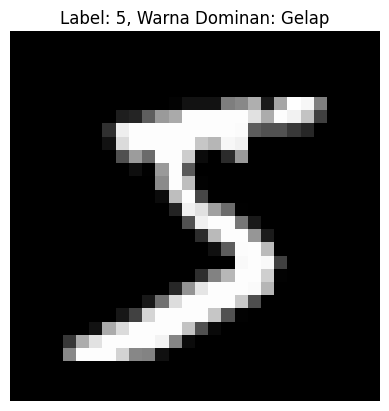

Gambar 2:
  Intensitas Dominan: 0
  Kategori Warna: Gelap


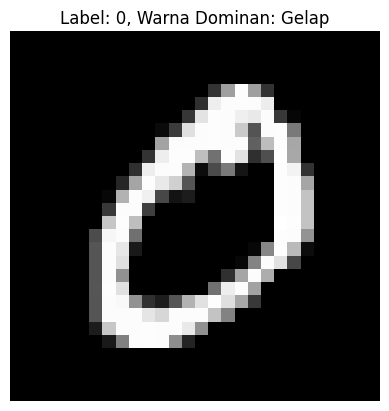

Gambar 3:
  Intensitas Dominan: 0
  Kategori Warna: Gelap


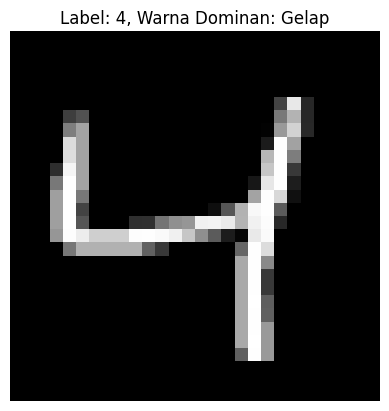

Gambar 4:
  Intensitas Dominan: 0
  Kategori Warna: Gelap


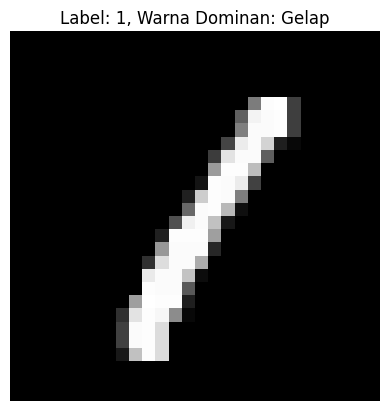

Gambar 5:
  Intensitas Dominan: 0
  Kategori Warna: Gelap


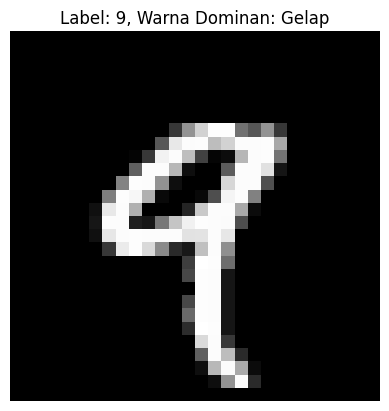

Gambar 6:
  Intensitas Dominan: 0
  Kategori Warna: Gelap


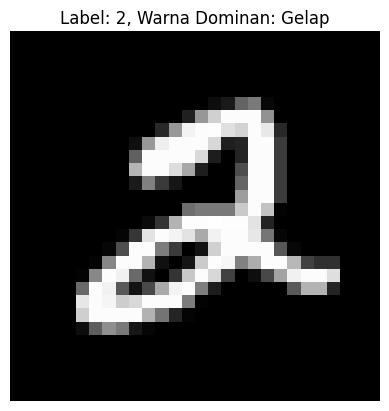

Gambar 7:
  Intensitas Dominan: 0
  Kategori Warna: Gelap


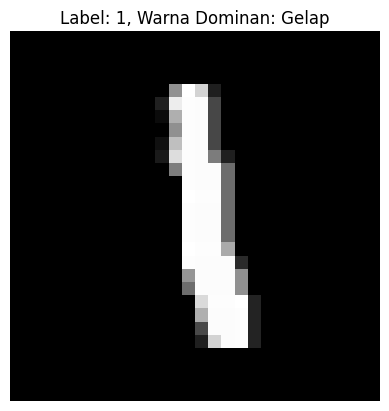

Gambar 8:
  Intensitas Dominan: 0
  Kategori Warna: Gelap


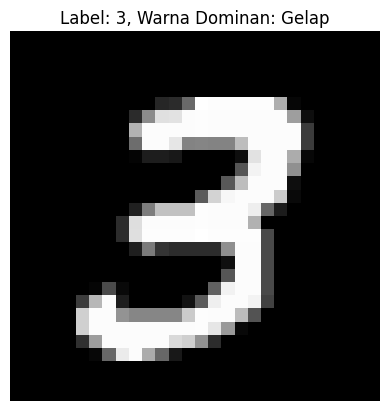

Gambar 9:
  Intensitas Dominan: 0
  Kategori Warna: Gelap


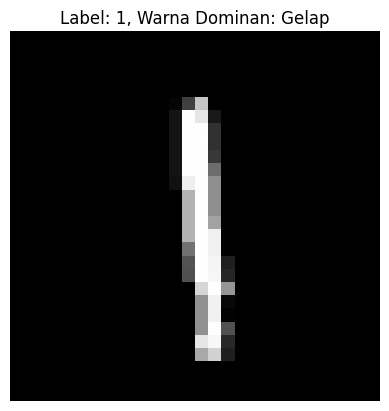

Gambar 10:
  Intensitas Dominan: 0
  Kategori Warna: Gelap


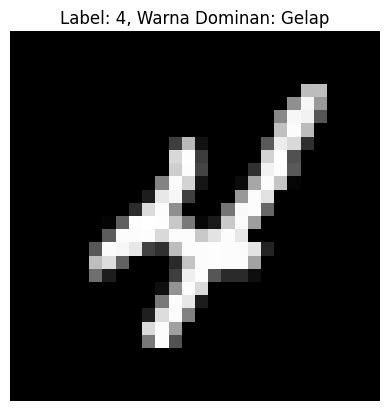

In [ ]:
# 10 gambar pertama beserta outputannya
for i in range(10):
    row = df.iloc[i]
    dominant_intensity = get_dominant_intensity(row)
    color_category = classify_dominant_color(dominant_intensity)

    print(f"Gambar {i+1}:")
    print(f"  Intensitas Dominan: {dominant_intensity}")
    print(f"  Kategori Warna: {color_category}")

    label = row[0]
    pixels = np.array(row[1:]).reshape(28, 28)
    plt.imshow(pixels, cmap='gray')
    plt.title(f"Label: {label}, Warna Dominan: {color_category}")
    plt.axis('off')
    plt.show()

Penjelasan singkat:  Kita melihat hasil dari langkah sebelumnya (intensitas dominan dan kategori warna) untuk 10 gambar pertama dalam dataset kita.

Penjelasan Output Postest:
Jadi, output pada postest ini menunjukkan hasil analisis warna dominan untuk 10 gambar pertama. Misalnya, jika output menunjukkan "Gambar 1: Intensitas Dominan: 10, Kategori Warna: Gelap", artinya pada gambar pertama, warna yang paling sering muncul adalah 10, dan karena 10 masuk dalam rentang 0-85, kita mengelompokkannya sebagai gambar yang cenderung gelap.

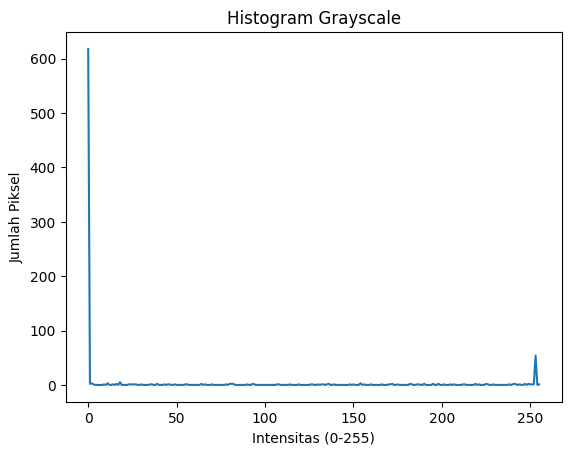

In [ ]:
#Ekstrasi fitur
def get_histogram(row):
    pixels = np.array(row[1:])
    hist, bins = np.histogram(pixels, bins=range(257))
    return hist

# Visualisasi histogram
sample_row = df.iloc[0]
histogram = get_histogram(sample_row)

plt.plot(histogram)
plt.title("Histogram Grayscale")
plt.xlabel("Intensitas (0-255)")
plt.ylabel("Jumlah Piksel")
plt.show()